## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA

## Load Dataset

In [2]:
# Load Bitcoin dataset
df = pd.read_csv("daily-website-visitors.csv")

# Display first rows
print(df.head())


   Row        Day  Day.Of.Week       Date Page.Loads Unique.Visits  \
0    1     Sunday            1  9/14/2014      2,146         1,582   
1    2     Monday            2  9/15/2014      3,621         2,528   
2    3    Tuesday            3  9/16/2014      3,698         2,630   
3    4  Wednesday            4  9/17/2014      3,667         2,614   
4    5   Thursday            5  9/18/2014      3,316         2,366   

  First.Time.Visits Returning.Visits  
0             1,430              152  
1             2,297              231  
2             2,352              278  
3             2,327              287  
4             2,130              236  


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Row                2167 non-null   int64 
 1   Day                2167 non-null   object
 2   Day.Of.Week        2167 non-null   int64 
 3   Date               2167 non-null   object
 4   Page.Loads         2167 non-null   object
 5   Unique.Visits      2167 non-null   object
 6   First.Time.Visits  2167 non-null   object
 7   Returning.Visits   2167 non-null   object
dtypes: int64(2), object(6)
memory usage: 135.6+ KB
None


## Data Preprocessing

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [5]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Row                  0
Day                  0
Day.Of.Week          0
Page.Loads           0
Unique.Visits        0
First.Time.Visits    0
Returning.Visits     0
dtype: int64


## Exploratory Data Analysis

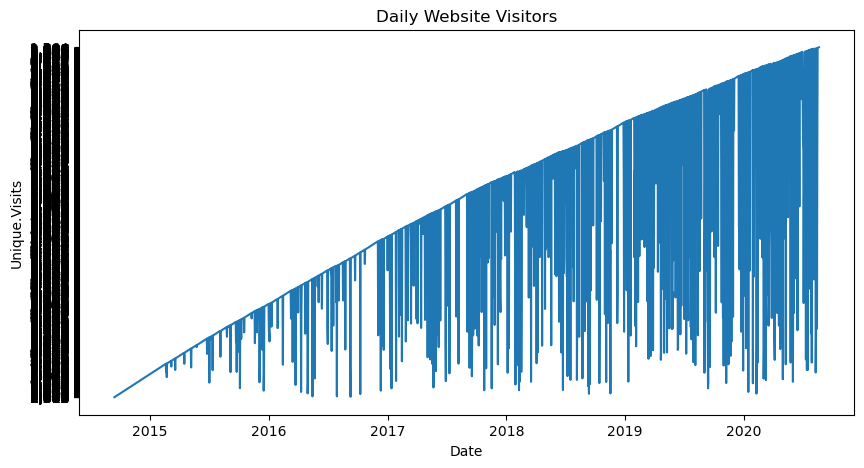

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Unique.Visits'])
plt.title("Daily Website Visitors")
plt.xlabel("Date")
plt.ylabel("Unique.Visits")
plt.show()

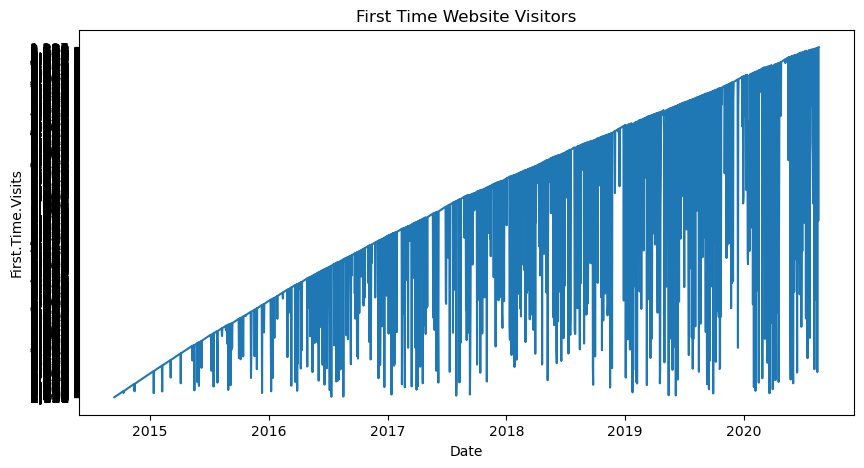

In [7]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['First.Time.Visits'])
plt.title("First Time Website Visitors")
plt.xlabel("Date")
plt.ylabel("First.Time.Visits")
plt.show()

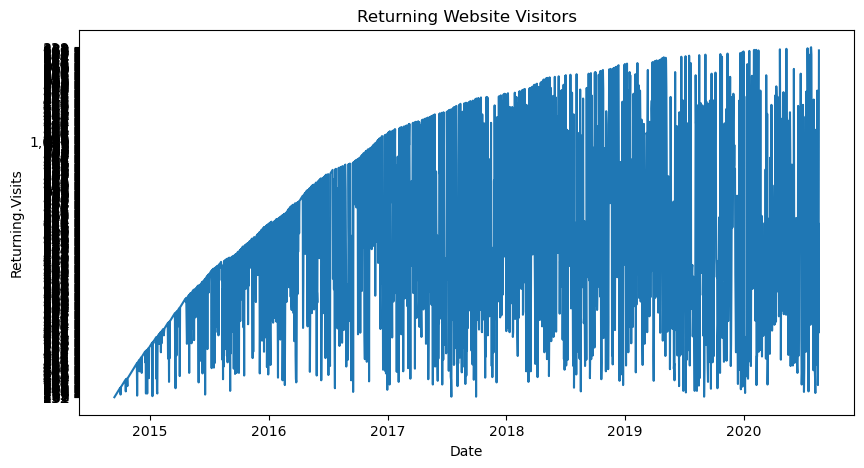

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Returning.Visits'])
plt.title("Returning Website Visitors")
plt.xlabel("Date")
plt.ylabel("Returning.Visits")
plt.show()

## Train-Test Split

In [9]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

## ARIMA Model

In [33]:
train['Unique.Visits'] = pd.to_numeric(train['Unique.Visits'], errors='coerce')
test['Unique.Visits'] = pd.to_numeric(test['Unique.Visits'], errors='coerce')

# Drop any NaN rows that resulted from conversion
train = train.dropna(subset=['Unique.Visits'])

arima_model = ARIMA(train['Unique.Visits'], order=(5,1,0))
arima_fit = arima_model.fit()

In [23]:
# Reset to clean integer index to avoid date index issues
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

# Then refit the model
arima_model = ARIMA(train['Unique.Visits'], order=(5,1,0))
arima_fit = arima_model.fit()

# Now forecast
arima_forecast = arima_fit.forecast(steps=len(test))
print(arima_forecast)

26     947.100997
27     909.876204
28     940.718514
29     909.085374
30     920.841932
          ...    
455    925.321292
456    925.321298
457    925.321287
458    925.321276
459    925.321283
Name: predicted_mean, Length: 434, dtype: float64


In [35]:
arima_mae = mean_absolute_error(y_true, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(y_true, arima_forecast))

NameError: name 'y_true' is not defined

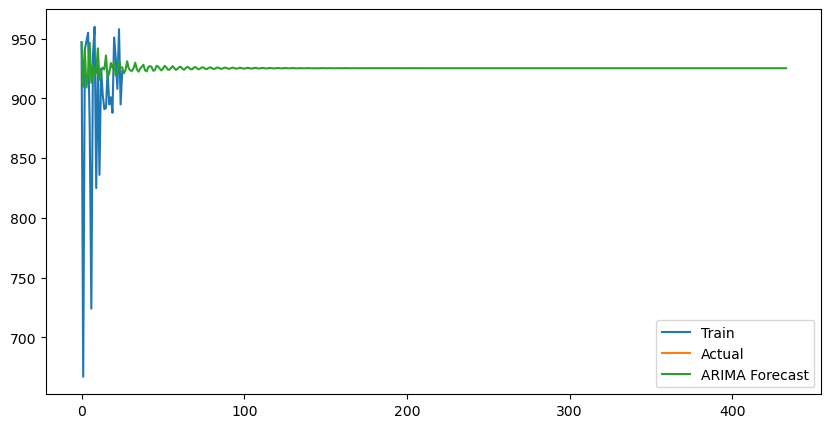

In [36]:
plt.figure(figsize=(10,5))
plt.plot(train.index, train['Unique.Visits'], label="Train")
plt.plot(test.index, test['Unique.Visits'], label="Actual")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.show()

## Feature Engineering for ML

In [37]:
df['day'] = df.index.day
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek

X = df[['day', 'month', 'dayofweek']]
y = df['Unique.Visits']

In [38]:
X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

## Random Forest Regressor

In [39]:
# Convert comma-formatted strings to float
y_train = pd.to_numeric(y_train.astype(str).str.replace(',', ''), errors='coerce')
y_test = pd.to_numeric(y_test.astype(str).str.replace(',', ''), errors='coerce')

# Also clean X_train/X_test if they have similar issues
X_train = X_train.apply(lambda col: pd.to_numeric(col.astype(str).str.replace(',', ''), errors='coerce') if col.dtype == object else col)
X_test = X_test.apply(lambda col: pd.to_numeric(col.astype(str).str.replace(',', ''), errors='coerce') if col.dtype == object else col)

In [40]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Predictions:", rf_preds)

Predictions: [3021.08  2330.965 1368.755 1762.225 3106.275 3044.7   2999.29  2796.3
 2227.525 1275.255 1612.97  2973.435 2929.165 2744.9   2653.875 1924.45
 1190.27  1550.04  2517.705 2488.14  2400.84  2233.915 2059.915 1082.79
 1390.01  2579.085 2630.555 2575.895 2484.58  2164.265 1210.885 1430.47
 2551.915 2567.18  2590.105 2603.56  2097.85  1213.695 1542.37  2685.66
 2700.44  2617.32  2475.67  2148.93  1255.53  1638.125 2634.15  2857.245
 2775.215 2622.905 2192.725 1201.755 1577.715 2735.725 2822.065 2719.015
 2548.805 2260.955 1267.92  1611.765 2759.555 2745.78  2652.715 2496.45
 2261.3   1301.625 1649.    2799.525 2787.46  2747.1   2749.545 2253.955
 1313.21  1640.67  2894.265 2961.355 2860.82  2823.89  2282.965 1271.245
 1563.445 2419.82  2870.425 2884.28  2872.395 2300.625 1433.745 2054.205
 3093.905 3166.625 3032.81  2911.17  2349.595 1458.69  1715.38  2787.78
 2976.955 2802.86  3013.32  2073.18  1306.85  1811.25  2955.405 3279.9
 3253.815 3392.89  2442.57  1392.385 2031.71  31

## ML Model Evaluation

In [41]:
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("\nRandom Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)


Random Forest MAE: 331.77610599078344
Random Forest RMSE: 432.0161051470785


## Final Comparison

In [42]:
print("\nMODEL COMPARISON")
print("----------------")
print("ARIMA  -> MAE:", arima_mae, " RMSE:", arima_rmse)
print("RF     -> MAE:", rf_mae, " RMSE:", rf_rmse)



MODEL COMPARISON
----------------


NameError: name 'arima_mae' is not defined